In [50]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from pyproj import Transformer

In [4]:
files_dir  = "./data_clip_exolabs"

#get all files in dir 
files = os.listdir(files_dir)
print(files)

#load tif 


tif_files = [] #LOAD all .tif 
for file in files:
    src = rasterio.open(os.path.join(files_dir, file))
    tif_files.append(src.read(1))


['2023-04-27+000_alps_HS_product.tif', '2023-04-19+000_alps_HS_product.tif', '2023-06-25+000_alps_HS_product.tif', '2023-05-06+000_alps_HS_product.tif', '2023-05-09+000_alps_HS_product.tif', '2023-06-14+000_alps_HS_product.tif', '2023-04-16+000_alps_HS_product.tif', '2023-04-28+000_alps_HS_product.tif', '2023-04-05+000_alps_HS_product.tif', '2023-06-07+000_alps_HS_product.tif', '2023-05-24+000_alps_HS_product.tif', '2023-05-15+000_alps_HS_product.tif', '2023-06-08+000_alps_HS_product.tif', '2023-06-10+000_alps_HS_product.tif', '2023-04-12+000_alps_HS_product.tif', '2023-04-23+000_alps_HS_product.tif', '2023-05-02+000_alps_HS_product.tif', '2023-06-21+000_alps_HS_product.tif', '2023-05-11+000_alps_HS_product.tif', '2023-04-30+000_alps_HS_product.tif', '2023-04-01+000_alps_HS_product.tif', '2023-05-20+000_alps_HS_product.tif', '2023-06-03+000_alps_HS_product.tif', '2023-05-12+000_alps_HS_product.tif', '2023-04-02+000_alps_HS_product.tif', '2023-05-23+000_alps_HS_product.tif', '2023-06-13

In [5]:
###EXPLORING THE FORMAT OF COORDINATE SYSTEM
with rasterio.open('./data_clip_exolabs/2023-04-01+000_alps_HS_product.tif') as src:
    # Check metadata
    print(src.crs)  # Coordinate Reference System (CRS)
    print(src.bounds)  # Bounding box (min, max) coordinates
    print(src.transform)

EPSG:3857
BoundingBox(left=829059.4892686082, bottom=5860743.433705239, right=938039.4892686082, top=5927163.433705239)
| 20.00, 0.00, 829059.49|
| 0.00,-20.00, 5927163.43|
| 0.00, 0.00, 1.00|


In [6]:
###EXPLORE AVALANCHE DATA FROM SLF

avalanche_data = pd.read_csv('./data_SLF_avalanche.csv')
print(avalanche_data.head())
print(avalanche_data.columns)

                           avalanche_id                   location  \
0  f9d63b0f-4a9d-443d-9df5-30e8ba818ef2   POINT(9.80967 46.832453)   
1  216c2530-d139-11ed-80fa-f54d650c1715   POINT(7.74259 46.055277)   
2  d58cf800-d139-11ed-af01-234d49385de9  POINT(7.737122 46.047328)   
3  36855710-d13a-11ed-af01-234d49385de9  POINT(7.736374 46.053393)   
4  6ab88170-d157-11ed-991a-6bfa9504affb  POINT(8.936376 46.932609)   

               trigger_date_time  trigger_date_time_accuracy_code  \
0  2023-04-01 10:44:00.000 +0200                                1   
1  2023-04-02 10:05:00.000 +0200                                0   
2  2023-04-02 09:55:00.000 +0200                                0   
3  2023-04-02 09:54:00.000 +0200                                0   
4  2023-04-02 14:20:00.000 +0200                                0   

  trigger_type avalanche_type  avalanche_size avalanche_moisture  \
0       PERSON           SLAB               2                DRY   
1    EXPLOSIVE           SLA

In [7]:
avalanche_data['location']
#string POINT(9.80967 46.832453)  
#remove POINT( and )
avalanche_data['location'] = avalanche_data['location'].str.replace('POINT(', '').str.replace(')', '')
avalanche_data['lat'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[1]))
avalanche_data['lon'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[0]))
print(avalanche_data['lon'])

0       9.809670
1       7.742590
2       7.737122
3       7.736374
4       8.936376
          ...   
1691    8.971368
1692    7.045566
1693    7.797743
1694    7.747613
1695    7.745373
Name: lon, Length: 1696, dtype: float64


In [8]:
date = avalanche_data['trigger_date_time'][0].split(' ')[0]
date 

'2023-04-01'

In [9]:
###FILTER ONLY POINT IN BOUNDS OF SAT DATA -> EXPORT SNOW DEPTH FROM SATELITE

def tif_path_from_date(date):
    return f"./data_clip_exolabs/{date}+000_alps_HS_product.tif"

new_df = pd.DataFrame(columns=['avalanche_id', 'location', 'trigger_date_time',
       'trigger_date_time_accuracy_code', 'trigger_type', 'avalanche_type',
       'avalanche_size', 'avalanche_moisture', 'start_zone_aspect', 'snow_depth_sat'])


transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)


for _, row in avalanche_data.iterrows():
    date = row['trigger_date_time'].split(' ')[0]
    tif_path = tif_path_from_date(date)

    with rasterio.open(tif_path) as tif_map:
        bounds = tif_map.bounds
        lon = row['lon']
        lat = row['lat']
        x_3857, y_3857 = transformer.transform(lon, lat)

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
                row_px, col_px = tif_map.index(x_3857, y_3857)
                snow_depth_sat = tif_map.read(1)[row_px, col_px]

                new_df = pd.concat([new_df, pd.DataFrame([row])], ignore_index=True)
                new_df.at[new_df.index[-1], 'snow_depth_sat'] = snow_depth_sat



In [54]:

#new_df.to_csv('./avalanche_with_sat.csv', index=False)
#make new df only for trigger_type = 'NATURAL'
natural_df = new_df[new_df['trigger_type'] == 'NATURAL']
natural_df.to_csv('./avalanche_with_sat.csv', index=False)
natural_df.shape

(31, 12)

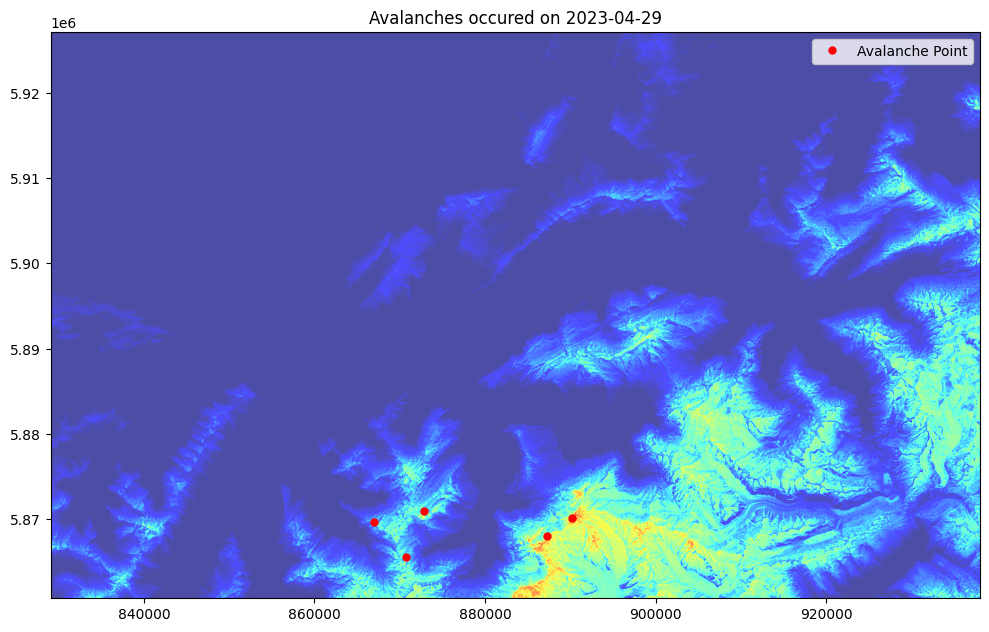

In [44]:
###plot avalanches on day 2023-04-01 from new_df

import matplotlib.pyplot as plt
from rasterio.plot import show  # Correct way to plot raster data
import rasterio
from pyproj import Transformer

tif_path = tif_path_from_date('2023-04-29')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
date = '2023-04-29'

with rasterio.open(tif_path) as src:
    band = src.read(1)
    transform = src.transform  # Affine transform for pixel <-> world coords

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the raster correctly using rasterio.plot.show
    show(band, transform=transform, cmap='jet', ax=ax, alpha=0.7)

    ax.set_title('Avalanches occured on ' + date)   


    # Plot avalanche points
    for _, row in natural_df.iterrows():
        if date in row['trigger_date_time']:
            lon = row['lon']
            lat = row['lat']
            x_3857, y_3857 = transformer.transform(lon, lat)
            ax.plot(x_3857, y_3857, 'ro', markersize=5, label='Avalanche Point')

    # Optional: show legend only once
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend([handles[0]], [labels[0]])

plt.tight_layout()
plt.show()


In [7]:
### ADD ELEVATION PROFILE 

Coordinate is out of bounds.


In [49]:
###WEATHER STATION DATA MAPPING 
file_path = '../Data/full_dataset.csv'

import pandas as pd

df = pd.read_csv(file_path)

# Extract the unique station codes along with their lon and lat
unique_stations = df[['station_code', 'lon', 'lat']].drop_duplicates()

unique_stations.dropna(inplace=True)
print(unique_stations)

from pyproj import Proj, transform


epsg4326 = Proj(init="epsg:4326")
epsg3857 = Proj(init="epsg:3857")

# Define the bounding box in EPSG:3857
bounding_box = {
    'left': 829059.4892686082,
    'bottom': 5860743.433705239,
    'right': 938039.4892686082,
    'top': 5927163.433705239
}
df = unique_stations
# Function to convert lon/lat to EPSG:3857
def lonlat_to_epsg3857(lon, lat):
    x, y = transform(epsg4326, epsg3857, lon, lat)
    return x, y

# Filter stations within the bounding box
stations_in_bbox = []

for index, row in df.iterrows():
    lon, lat = row['lon'], row['lat']
    
    # Convert to EPSG:3857
    x, y = lonlat_to_epsg3857(lon, lat)
    
    # Check if the station is within the bounding box
    if bounding_box['left'] <= x <= bounding_box['right'] and bounding_box['bottom'] <= y <= bounding_box['top']:
        stations_in_bbox.append(row['station_code'])

# Output the stations that are within the bounding box
print("Stations within the bounding box (EPSG:3857):")
print(stations_in_bbox)


/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_52568/1728435207.py:5: DtypeWarning: Columns (91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6


      station_code       lon        lat
3653          DIA2  7.241038  46.315405
3696          GLA2  9.037583  46.996629
3825          TUJ3  8.740224  46.647032
3913          OBW2  8.315956  46.545222
3957          URS2  8.513860  46.586787
...            ...       ...        ...
11082         KES2  9.898140  46.621285
11122         LAG2  9.744580  46.451358
11162         FUL2  7.089661  46.194685
11163         ILI2  6.827797  46.191356
11203         FIR2  8.064403  46.668777

[95 rows x 3 columns]
Stations within the bounding box (EPSG:3857):
['OBW2', 'GAD2', 'TIT2', 'FAE2', 'GUT2', 'OTT2', 'ROA2', 'SCH2', 'MAE2', 'SCB2', 'OBW3', 'TIT2', 'GAD2', 'OBW3', 'GUT2', 'ROA2', 'FIR2']


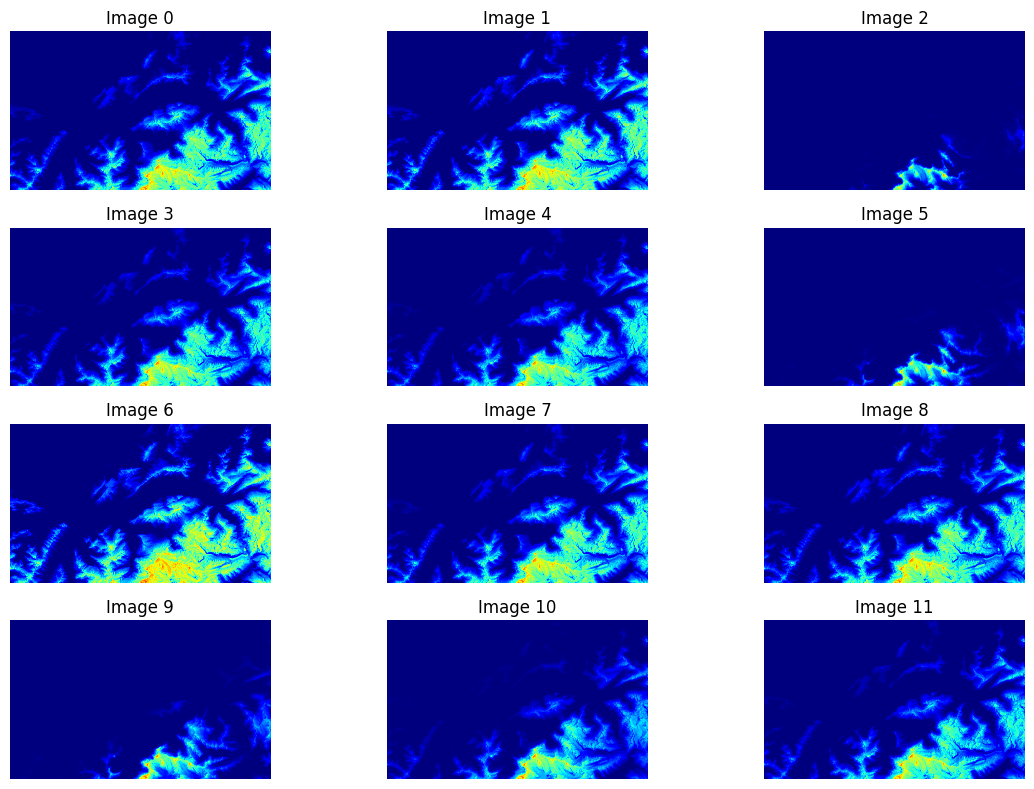

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(12, 8))  

for i in range(12):
    ax = axes[i // 3, i % 3]
    ax.imshow(tif_files[i], cmap='jet') 
    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


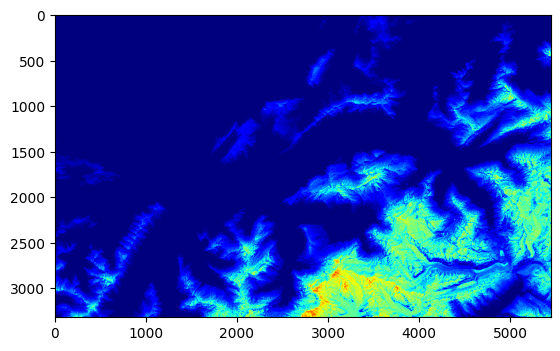

In [30]:
plt.imshow(tif_files[0], cmap='jet')

In [59]:
### WEATHER STATION DATA



# Load station metadata
stations_df = pd.read_csv('./meta_stations.csv', sep=';')

# Transformer from EPSG:4326 to EPSG:3857
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transform and filter
def is_in_bounds(lon, lat):
    x, y = transformer.transform(lon, lat)
    return (829059.4892686082 <= x <= 938039.4892686082) and (5860743.433705239 <= y <= 5927163.433705239)

stations_df['in_bounds'] = stations_df.apply(lambda row: is_in_bounds(row['station_coordinates_wgs84_lon'], row['station_coordinates_wgs84_lat']), axis=1)
stations_in_bounds = stations_df[stations_df['in_bounds']]

print(stations_in_bounds["station_abbr"])


23     BRZ
52     ENG
56     FLU
58     FRU
61     GIH
69     GRH
79     INT
80     JUN
94     MER
143    THU
144    TIT
146    ULR
Name: station_abbr, dtype: object


In [61]:
import requests
import os
from datetime import datetime, timedelta

# List of station IDs
station_ids = ['BRZ', 'ENG', 'FLU', 'FRU', 'GIH', 'GRH', 'INT', 'JUN', 'MER', 'THU', 'TIT', 'ULR']

# Date range
start_date = datetime(2023, 4, 1)
end_date = datetime(2023, 6, 1)

# Base URL for items endpoint
base_url = 'https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items'

# Directory to save downloaded files
output_dir = 'meteoswiss_data'
os.makedirs(output_dir, exist_ok=True)

# Iterate over each station
for station_id in station_ids:
    # Construct query URL
    query_url = f"{base_url}?station_id={station_id}&datetime={start_date.strftime('%Y-%m-%d')}/{end_date.strftime('%Y-%m-%d')}"
    
    # Send GET request
    print(query_url)
    response = requests.get(query_url)
    if response.status_code == 200:
        items = response.json().get('features', [])
        for item in items:
            # Get asset URL
            assets = item.get('assets', {})
            for asset_key, asset_info in assets.items():
                href = asset_info.get('href')
                if href and href.endswith('.csv'):
                    # Download the CSV file
                    filename = f"{station_id}_{item['properties']['datetime'][:10]}.csv"
                    file_path = os.path.join(output_dir, filename)
                    csv_response = requests.get(href)
                    if csv_response.status_code == 200:
                        with open(file_path, 'wb') as f:
                            f.write(csv_response.content)
                        print(f"Downloaded: {filename}")
                    else:
                        print(f"Failed to download {filename}")
    else:
        print(f"Failed to retrieve items for station {station_id}")


def get_historical_files(station_data):
    historical_files = []
    assets = station_data.get("assets", {})
    for filename, meta in assets.items():
        if "historical" in filename:
            historical_files.append({
                "station": station_data.get("properties", {}).get("title", "Unknown"),
                "filename": filename,
                "url": meta.get("href"),
                "created": meta.get("created"),
                "updated": meta.get("updated")
            })
    return historical_files

get_historical_files(station_data)

https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=BRZ&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=ENG&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=FLU&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=FRU&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=GIH&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=GRH&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=INT&datetime=2023-04-01/2023-06-01
https://data.geo.admin.ch/api/stac/v1/collections/ch.meteoschweiz.ogd-smn/items?station_id=JUN&datetime=2023-04-01/202